<a href="https://colab.research.google.com/github/rafaelchamorro/AmigoSecreto-OneDesafio/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# Tiene formato de código
```
<H1>Desafio Alura Store</H1>

<p>Hola, mi nombre es Rafael Chamorro, soy Ingeniero Bioquímico y estudiante en Alura Latam de Data Science. En este desafío, analizaré las ventas y el rendimiento de cuatro tiendas para ayudar al señor "Juan" a decidir cuál de ellas debería vender para invertir en un nuevo negocio.</p>
    
<h2>Objetivo del Desafío</h2>
 <p>El objetivo es evaluar cuál de las cuatro tiendas tiene un desempeño menor, basándonos en cinco aspectos clave:</p>
    <ul>
        <li>Facturación total de cada tienda.</li>
        <li>Categorías más populares de cada tienda.</li>
        <li>Promedio de evaluación de los clientes.</li>
        <li>Productos más y menos vendidos en cada tienda.</li>
        <li>Costo promedio del envío desde la tienda hasta el cliente.</li>
    </ul>

 <h2>Herramientas y Recursos</h2>
<p>Utilizaré GitHub y Google Colab para el manejo de datos y análisis.</p>

# <h2>¡Manos a la obra!</h2>


### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



<ipython-input-4-675abc277d43>:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.2f}'.format(x) for x in current_values])


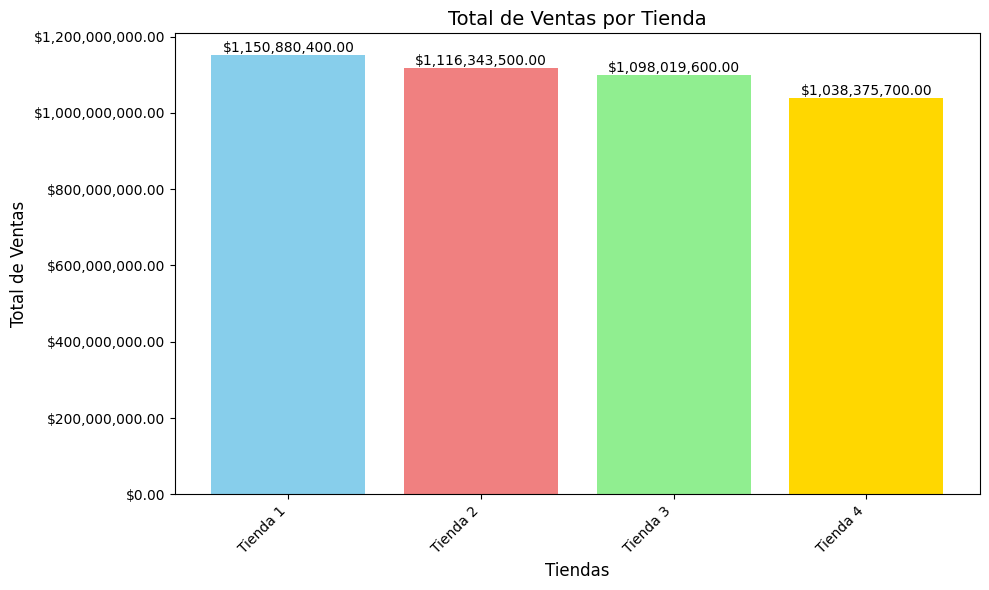

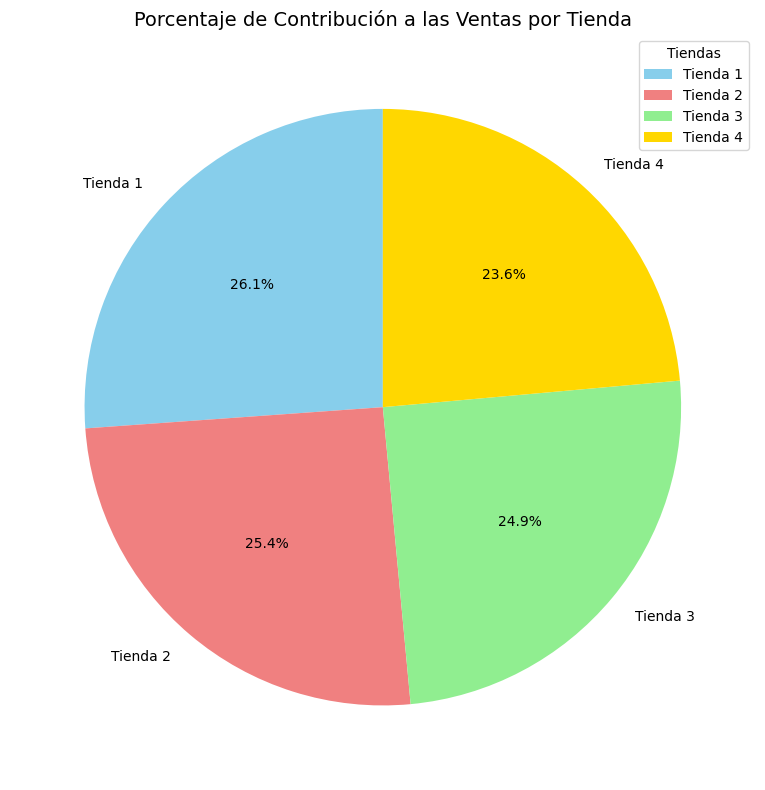

In [4]:
import matplotlib.pyplot as plt
# Facturación por tienda
total_sales_tienda1 = tienda['Precio'].sum()
total_sales_tienda2 = tienda2['Precio'].sum()
total_sales_tienda3 = tienda3['Precio'].sum()
total_sales_tienda4 = tienda4['Precio'].sum()

# Listado de totales
total_sales = [total_sales_tienda1, total_sales_tienda2, total_sales_tienda3, total_sales_tienda4]
stores = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Facturación total del Negocio
total_revenue = sum(total_sales)

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(stores, total_sales, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.ylabel('Total de Ventas', fontsize=12)
plt.xlabel('Tiendas', fontsize=12)
plt.title('Total de Ventas por Tienda', fontsize=14)
plt.xticks(rotation=45, ha='right')


# Format the y-axis as currency
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.2f}'.format(x) for x in current_values])

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, '${:,.2f}'.format(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_sales, labels=stores, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Porcentaje de Contribución a las Ventas por Tienda', fontsize=14)

# Add data labels
plt.legend(title="Tiendas")
plt.tight_layout()
plt.show()


In [15]:

import pandas as pd

# Análisis de facturación por ciudad y costos de envío
def analizar_facturacion_envios(tienda, nombre_tienda):
    # Agrupar por ciudad y calcular la facturación total
    facturacion_ciudad = tienda.groupby('Lugar de Compra')['Precio'].sum()

    # Calcular el costo total de envíos por ciudad
    costo_envio_ciudad = tienda.groupby('Lugar de Compra')['Costo de envío'].sum()

    # Crear un DataFrame con la información
    analisis_df = pd.DataFrame({
        'Facturación': facturacion_ciudad,
        'Costo de Envío': costo_envio_ciudad
    })

    # Calcular la diferencia entre facturación y costo de envío
    analisis_df['Diferencia'] = analisis_df['Facturación'] - analisis_df['Costo de Envío']

    # Agregar el nombre de la tienda como columna
    analisis_df['Tienda'] = nombre_tienda

    return analisis_df

# Aplicar la función a cada tienda
analisis_tienda1 = analizar_facturacion_envios(tienda, 'Tienda 1')
analisis_tienda2 = analizar_facturacion_envios(tienda2, 'Tienda 2')
analisis_tienda3 = analizar_facturacion_envios(tienda3, 'Tienda 3')
analisis_tienda4 = analizar_facturacion_envios(tienda4, 'Tienda 4')

# Concatenar los resultados en un solo DataFrame
analisis_total = pd.concat([analisis_tienda1, analisis_tienda2, analisis_tienda3, analisis_tienda4])

# Mostrar el DataFrame resultante
analisis_total


,Facturación,Costo de Envío,Diferencia,Tienda
Lugar de Compra,,,,
Armenia,4615700.0,242400.0,4373300.0,Tienda 1
Barranquilla,32907700.0,1778100.0,31129600.0,Tienda 1
Bogotá,440005000.0,23434800.0,416570200.0,Tienda 1
Bucaramanga,17579200.0,948200.0,16631000.0,Tienda 1
Cali,154493700.0,8158200.0,146335500.0,Tienda 1
...,...,...,...,...
Riohacha,23684700.0,1274800.0,22409900.0,Tienda 4
Santa Marta,13218600.0,701600.0,12517000.0,Tienda 4
Soacha,3149000.0,179000.0,2970000.0,Tienda 4


<ipython-input-19-774aac98883a>:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.2f}'.format(x) for x in current_values])


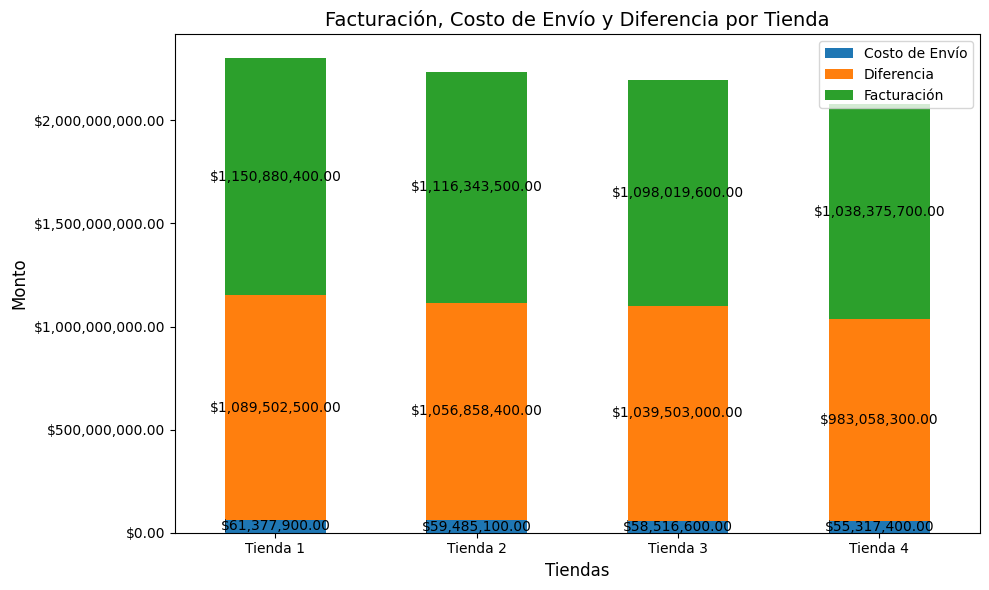

In [19]:
import matplotlib.pyplot as plt

# Crear el gráfico de barras apiladas
analisis_total.pivot_table(index='Tienda',
                           values=['Facturación', 'Costo de Envío', 'Diferencia'],
                           aggfunc='sum').plot(kind='bar', stacked=True, figsize=(10, 6))

plt.ylabel('Monto', fontsize=12)  # Etiqueta del eje Y
plt.xlabel('Tiendas', fontsize=12)  # Etiqueta del eje X
plt.title('Facturación, Costo de Envío y Diferencia por Tienda', fontsize=14)
plt.xticks(rotation=0) # Rotación de las etiquetas del eje X

# Formatear el eje Y como moneda
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.2f}'.format(x) for x in current_values])

# Agregar etiquetas de datos
for p in plt.gca().patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    plt.text(x+width/2, y+height/2, '${:,.2f}'.format(height), ha='center', va='center')

plt.tight_layout()
plt.show()




# 2. Ventas por categoría

# 3. Calificación promedio de la tienda


# 4. Productos más y menos vendidos

# 5. Envío promedio por tienda